In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# dataset: https://www.kaggle.com/code/mragpavank/pima-indians-diabetes-database/input
data_path = "E:/IAD/INTERN/01_diabetes/data/diabetes.csv"
df = pd.read_csv(data_path)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [16]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [42]:
num_class0 = len(df[df.Outcome == 0])
num_class1 = len(df[df.Outcome == 1])
print("Number of class 0: ", num_class0)
print("Number of class 1: ", num_class1)

Number of class 0:  500
Number of class 1:  268


In [7]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# 1. Diabete classification using Logistic Rregression

references:
- https://machinelearningcoban.com/2017/01/27/logisticregression/
- https://www.analyticsvidhya.com/blog/2022/02/implementing-logistic-regression-from-scratch-using-python/

## Implement LogisticRegression

In [8]:
import numpy as np
from numpy import dot, log, e, shape
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [9]:
# standardization of data
def standardize(X_tr):
    for i in range(shape(X_tr)[1]):
        X_tr[:,i] = (X_tr[:,i] - np.mean(X_tr[:,i]))/np.std(X_tr[:,i]) 


# f1 score
def f1_score(y, y_hat):
    tp, tn, fp, fn = 0, 0, 0, 0
    for i in range(len(y)):
        if y[i] == 1 and y_hat[i] == 1:
            tp += 1
        elif y[i] == 0 and y_hat[i] == 0:
            tn += 1
        elif y[i] == 0 and y_hat[i] == 1:
            fp += 1
        elif y[i] == 1 and y_hat[i] == 0:
            fn += 1
    precison = tp/(tp+fn)
    recall = tp/(tp+fp)
    f1_score = 2*(precison*recall)/(precison+recall)
    return f1_score

In [10]:
class LogisticRegression():

    # sigmoid function
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))


    # initializing parameters
    def initialize(self, X):
        weights = np.zeros((shape(X)[1] + 1, 1))
        X = np.c_[np.ones((shape(X)[0], 1)), X]
        return weights, X


    # gradient descent
    def fit(self, X, y, alpha=0.001, iterations=400):
        weights, X = self.initialize(X)
        # cost function
        def cost(theta):
            z = dot(X, theta)
            cost0 = y.T.dot(log(self.sigmoid(z)))
            cost1 = (1 - y).T.dot(log(1 - self.sigmoid(z)))
            cost = -(cost0 + cost1) / len(y)
            return cost
        cost_list = np.zeros(iterations,)
        for i in range(iterations):  
            weights = weights - alpha*dot(X.T, self.sigmoid(dot(X, weights)) - np.reshape(y, (len(y), 1)))  
            cost_list[i] = cost(weights)
        self.weights = weights
        return cost_list


    # prediction
    def predict(self, X):
        z = dot(self.initialize(X)[1], self.weights)
        lis = []
        for i in self.sigmoid(z):
            if i > 0.5:
                lis.append(1)
            else:
                lis.append(0)
        return np.array(lis)



In [11]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)
standardize(x_train)
standardize(x_test)
model = LogisticRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
y_train_predicted = model.predict(x_train)

f1_score_train = f1_score(y_train, y_train_predicted)
f1_score_test = f1_score(y_test, y_pred)

print("f1_score_train: ", f1_score_train)
print("f1_score_test: ", f1_score_test)


f1_score_train:  0.635
f1_score_test:  0.651685393258427


C:\Users\JOS UC\AppData\Local\Temp\ipykernel_2896\2601443504.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cost_list[i] = cost(weights)


## LogisticRegression using scikit-learn

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score

In [13]:
model = LogisticRegression()
model.fit(x_train, y_train)

pred = model.predict(x_test)

accuracy = accuracy_score(y_test, pred)
print(f'accuracy = {accuracy}')
precision = precision_score(y_test, pred)
print(f'precision = {precision}')
recall = recall_score(y_test, pred)
print(f'recall = {accuracy}')
f1 = f1_score(y_test, pred)
print(f'f1 = {f1}')

accuracy = 0.7987012987012987
precision = 0.6904761904761905
recall = 0.7987012987012987
f1 = 0.651685393258427


# 2. Diabete classification using XGBoost

inferences:
- https://www.datacamp.com/tutorial/xgboost-in-python
- https://gist.github.com/pb111/cc341409081dffa5e9eaf60d79562a03

## Implement XGBoost

## XGBoost using XGBoost framework

In [41]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score


# declare parameters
params = {
            'objective':'binary:logistic',
            'max_depth': 4,
            'alpha': 10,
            'learning_rate': 0.01,
            'n_estimators':500
        }

xgb_clf = XGBClassifier(**params)
xgb_clf.fit(x_train, y_train)

# make predictions on test data
y_pred = xgb_clf.predict(x_test)

print('XGBoost model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

XGBoost model accuracy score: 0.7857


# 3. Diabete classification using Random Forst (RF)

references:
- https://www.datacamp.com/tutorial/random-forests-classifier-python
- https://www.geeksforgeeks.org/random-forest-regression-in-python/
- https://www.analyticsvidhya.com/blog/2021/06/understanding-random-forest/

## RF using sklearn

In [43]:
from sklearn.ensemble import RandomForestClassifier


model = RandomForestClassifier()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print('Random Forest model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Random Forest model accuracy score: 0.7987


In [44]:
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

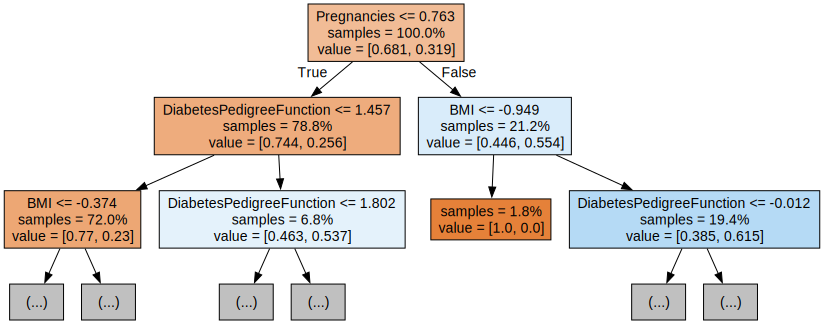

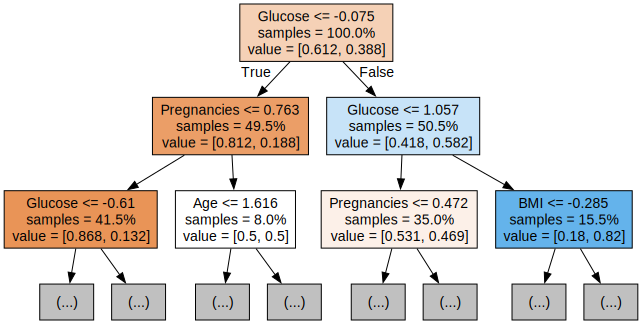

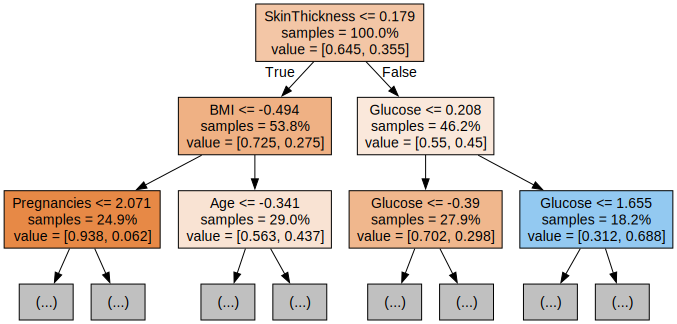

In [56]:
new_df = df.iloc[:, :-1]
# print(new_df)
for i in range(3):
    tree = model.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=new_df.columns,  
                               filled=True,  
                               max_depth=2, 
                               impurity=False, 
                               proportion=True)
    graph = graphviz.Source(dot_data)
    display(graph)

## implement code RF

# 4. Diabete classification using Support Vector Machines (SVM)

references:
- https://www.analyticsvidhya.com/blog/2017/09/understaing-support-vector-machine-example-code/
- https://www.geeksforgeeks.org/implementing-svm-and-kernel-svm-with-pythons-scikit-learn/

In [57]:
from sklearn import svm
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)

ksvm = svm.SVC(kernel='rbf',
               gamma=0.1,
               C=10.0)
 
# Train the model on the training data
ksvm.fit(X_train, y_train)
 
# Evaluate the model on the test data
accuracy = ksvm.score(X_test, y_test)
print('Accuracy:', accuracy)

Accuracy: 0.7662337662337663
